# Coursework Assessment: Question 1
---

## Q1(a) — Turing Machine for \($1^n 0 1^m \mapsto 1^{n+m}$\)

### Overall Idea
Use the middle delimiter `0` as a “bubble” marker and repeatedly apply the local swap:
\[ $01 \;\Rightarrow\; 10$ \]
This moves the delimiter `0` **one cell to the right** each time, effectively transferring one `1` from the right block into the left block. When there is no `1` immediately to the right of the delimiter (i.e., we see `0`), bubbling stops; at that moment the tape contains a single block \(1^{n+m}\) followed by a `0`. Finally, move the head back to the leftmost `1` and halt.

### Notation
- `q0`: Scan right across the left block \(1^n\) to find the delimiter `0`.
- `qInspect`: Positioned **one cell right of the delimiter**; decides whether to keep bubbling.
- `qWL`, `qW1`, `qBack`, `qDelim`: Implement one bubbling step (swap \(01 \to 10\)).
- `qReturn`, `qGoLeft`: Return to the left end of the merged block.
- `qHalt`: Halt while scanning the leftmost `1`.

Tape alphabet: \(\{0,1\}\), where `0` also serves as the blank symbol.

Actions used:
- `L`, `R`
- `W1` = write `1`
- `W0` = write `0`
- `T` = terminate

### Transition table \($\delta$\)
Each instruction is in format:
\[
$(\text{current state},\ \text{reading},\ \text{action},\ \text{next state})$
\]

#### Block A — scan to the delimiter
- \($(q0,\ 1,\ R,\ q0)$\)  
- \($(q0,\ 0,\ R,\ qInspect)$\)

#### Block B — bubble the delimiter rightward by swapping \(01 \to 10\)
**Case 1: the symbol right of the delimiter is `1` (perform one swap).**

- \($(qInspect,\ 1,\ W0,\ qWL)$\)  
- \($(qWL,\ 0,\ L,\ qW1)$\)  
- \($(qW1,\ 0,\ W1,\ qBack)$\)  
- \($(qBack,\ 1,\ R,\ qDelim)$\)  
- \($(qDelim,\ 0,\ R,\ qInspect)$\)

**Case 2: the symbol right of the delimiter is `0` (stop bubbling).**

- \($(qInspect,\ 0,\ L,\ qReturn)$\)

#### Block C — return to the leftmost `1` and halt

- \($(qReturn,\ 0,\ L,\ qGoLeft)$\)  
- \($(qGoLeft,\ 1,\ L,\ qGoLeft)$\)  
- \($(qGoLeft,\ 0,\ R,\ qHalt)$\)  
- \($(qHalt,\ 1,\ T,\ qHalt)$\)

---
## Q1(b) - Turing Machine Coding

In [1]:
# ==================== Q1(b) ====================
import random

def build_tm_transitions():
# Build and return the full TM transition table that encodes the 1^n 0 1^m -> 1^(n+m) behavior.
    """
    Transition function of the Turing machine.
    Tape alphabet: {'0', '1'}, where '0' is also used as blank.
    Actions: L, R, W1, W0, T (halt).
    """
    delta = {}

# A: Scan right in the left block 1^n until the delimiter 0.
    delta[("q0", "1")] = ("R", "q0")
    delta[("q0", "0")] = ("R", "qInspect")

# B: Move the delimiter 0 rightward by repeatedly applying 01 -> 10.
    delta[("qInspect", "1")] = ("W0", "qWL")
    delta[("qWL", "0")] = ("L", "qW1")
    delta[("qW1", "0")] = ("W1", "qBack")
    delta[("qBack", "1")] = ("R", "qDelim")
    delta[("qDelim", "0")] = ("R", "qInspect")

# Stop bubbling when no 1 exists to the right.
    delta[("qInspect", "0")] = ("L", "qReturn")

# C: Return to the leftmost 1 and halt.
    delta[("qReturn", "0")] = ("L", "qGoLeft")
    delta[("qGoLeft", "1")] = ("L", "qGoLeft")
    delta[("qGoLeft", "0")] = ("R", "qHalt")
    delta[("qHalt", "1")] = ("T", "qHalt")

    return delta

def ensure_tape_cell(tape, head):
# Guarantee head points to a valid cell by extending tape left/right with blank symbol '0' when out of bounds.
    """
    Ensure tape[head] is valid by extending the tape with '0' when needed.
    """
    while head < 0:
        tape.insert(0, "0")
        head += 1
    while head >= len(tape):
        tape.append("0")
    return tape, head

def run_tm(input_str, transitions=None, max_steps=1_000_000, verbose=False):
# Execute the TM step-by-step on input string and return output plus final machine state details.
    """
    Simulate input 1^n 0 1^m and output merged 1^{n+m}.
    Return (output_ones, final_tape, final_head, steps_used).
    """
    if transitions is None:
        transitions = build_tm_transitions()

    if not input_str or input_str[0] != "1":
        raise ValueError("Input tape must start with '1'.")

    # Add one trailing blank '0' to simplify right-side checks.
    tape = list(input_str) + ["0"]
    head = 0
    state = "q0"
    steps = 0

    while steps < max_steps:
        tape, head = ensure_tape_cell(tape, head)
        sym = tape[head]

        transition = transitions.get((state, sym))
        if transition is None:
            raise RuntimeError(f"No transition for state={state}, sym={sym}, head={head}.")
        action, next_state = transition

        if verbose:
            left = max(0, head - 10)
            right = min(len(tape), head + 11)
            print(f"step={steps:6d} state={state:8s} read={sym} action={action:2s} next={next_state:8s}")
            print("".join(tape[left:right]))
            print(" " * (head - left) + "^")

        if action == "L":
            head -= 1
        elif action == "R":
            head += 1
        elif action == "W1":
            tape[head] = "1"
        elif action == "W0":
            tape[head] = "0"
        elif action == "T":
            break
        else:
            raise ValueError(f"Action Error")

        state = next_state
        steps += 1
    else:
        raise RuntimeError("Steps Error")

    if "1" not in tape:
        return "", tape, head, steps
    first_one = tape.index("1")

    j = first_one
    while j < len(tape) and tape[j] == "1":
        j += 1
    output = "".join(tape[first_one:j])
    return output, tape, head, steps

# ------------------------------------------------------------------
# Q1(b) — Explicit demonstration on two concrete test cases
# Case 1: n=3, m=2  -> input  "111 0 11",  expected output "11111"
# Case 2: n=1, m=4  -> input  "1 0 1111",  expected output "11111"
# These fixed cases make the TM behaviour easy to verify by inspection.
# ------------------------------------------------------------------
demo_cases = [
    ("1110" + "11",  3, 2),   # n=3, m=2 -> 1^5
    ("10" + "1111",  1, 4),   # n=1, m=4 -> 1^5
    ("111",          3, 0),   # n=3, m=0 (no right block) -> 1^3
]
print("\n--- Q1(b) explicit demonstration ---")
for input_str, n, m in demo_cases:
    output, _, _, steps = run_tm(input_str)
    expected = "1" * (n + m)
    status = "PASS" if output == expected else "FAIL"
    print(f"  Input: {input_str!r:15s} -> output: {output!r:10s} "
          f"(expected {expected!r}) [{status}]  steps={steps}")

# ------------------------------------------------------------------
# Q1(b) — Randomised stress test across 20 cases
# Verifies the TM for arbitrary n in [1,20] and m in [0,20].
# ------------------------------------------------------------------
rng = random.Random(42)
num_tests = 20
max_m = 20
max_n = 20
failed_tests = 0
for _ in range(num_tests):
    n = rng.randint(1, max_n)  # Enforce leftmost symbol is '1'.
    m = rng.randint(0, max_m)
    input_str = "1" * n + "0" + "1" * m
    if input_str[0] != "1":
        failed_tests += 1
        print(f"Test failed: invalid random tape {input_str}")
        continue
    output, final_tape, final_head, steps = run_tm(input_str)
    expected_output = "1" * (n + m)
    if output != expected_output:
        failed_tests += 1
        print(
            f"Test failed: input={input_str}, expected={expected_output}, got={output}, "
            f"head={final_head}, steps={steps}"
        )
if failed_tests == 0:
    print(f"All {num_tests} random tests passed.")
else:
    print(f"{failed_tests}/{num_tests} random tests failed.")
    


--- Q1(b) explicit demonstration ---
  Input: '111011'        -> output: '11111'    (expected '11111') [PASS]  steps=22
  Input: '101111'        -> output: '11111'    (expected '11111') [PASS]  steps=30
  Input: '111'           -> output: '111'      (expected '111') [PASS]  steps=10
All 20 random tests passed.


---

## Q1(c) - Show that $ [\log_2(n+1)] (n\in\mathbb N)$ is a recursive function.

Let
$f(n) = [\log_2(n+1)]$.
Equivalently, $ f(n) $ is the **least** natural number $ k $ such that
$2^k \ge n+1$.
So that
$f(n) = \mu k\; (2^k \ge n+1)$,
where $ \mu k $ denotes “the least $ k $” satisfying the property.

### Step 1: Show the building blocks are primitive recursive
1. The successor function $S(n)=n+1$ is primitive recursive.
2. Addition and multiplication are primitive recursive.
3. The exponentiation-by-2 function $\mathrm{pow2}(k)=2^k$ is primitive recursive, because it can be defined by primitive recursion:
   $\mathrm{pow2}(0)=1$ and $\mathrm{pow2}(k+1)=2\cdot\mathrm{pow2}(k)$.

4. Define a primitive recursive “greater-or-equal” predicate using truncated subtraction.
Let truncated subtraction be $\operatorname{tsub}(x,y)=\max(x-y,0)$, which is primitive recursive. Define
$\mathrm{GE}(x,y)=1$ if $x\ge y$, and $\mathrm{GE}(x,y)=0$ otherwise.
One standard way is:
$\mathrm{GE}(x,y)=\mathrm{isZero}(\operatorname{tsub}(y,x))$,
where $\mathrm{isZero}(t)=1$ if $t=0$, and $\mathrm{isZero}$ is primitive recursive.

Hence the predicate
$P(n,k) = \mathrm{GE}(\mathrm{pow2}(k),\, n+1)$
is primitive recursive.

### Step 2: Bound the search
For every $n\in\mathbb N$, $2^{n+1} \ge n+1$.

Therefore, there **always exists** some $k \le n+1$ such that $2^k \ge n+1$.
So the least such $ k $ can be found by a **bounded search**:
$f(n) = \mu k \le n+1\; P(n,k)$.

### Step 3: Conclusion
Since $P(n,k)$ is primitive recursive and the search is bounded by $ n+1 $, it follows that
$f(n)=[\log_2(n+1)]$
is a recursive function.

Therefore, $ [\log_2(n+1)] $ is recursive for all $n\in\mathbb N$.

---
## Q1(d) - Binary Search

In [3]:
# ==================== Q1(d) ====================
def binarysearch(lst, target, lower=None, upper=None):
    """
    Recursive binary search on a sorted list.

    The function divides the search interval in half on each recursive call,
    following the algorithm specified in Q1(d):
      - Step 1: initialise lower=0, upper=n-1 on the first call.
      - Step 2: if upper < lower, the target is absent -> return 'fail'.
      - Step 3: middle = floor((lower + upper) / 2).
      - Step 4: if lst[middle] == target, return middle.
      - Step 5: recurse into the left or right half depending on the comparison.

    Parameters
    ----------
    lst    : list, sorted in non-decreasing order
    target : value to locate
    lower  : int, left bound of the current search interval (default: 0)
    upper  : int, right bound of the current search interval (default: len(lst)-1)

    Returns
    -------
    int or str
        Index of target if found; 'fail' otherwise.

    Design decisions
    ----------------
    * Default parameters (lower=None, upper=None) let the caller use the
      two-argument form binarysearch(lst, target) while allowing recursive
      calls to pass updated bounds explicitly.
    * The variable name 'lst' avoids shadowing the built-in 'list'.
    * The recursive structure directly mirrors the algorithm in the question sheet.
    * Step 5 in the question sheet reads "If target < middle then upper = middle-1."
      The symbol 'middle' there is the INDEX (an integer position), but the intended
      comparison is with the LIST VALUE lst[middle].  Comparing a search target against
      a positional index would be meaningless for a general sorted list; the only
      sensible interpretation is target < lst[middle], which is what the code implements.

    Tests
    -----
    See run_tests_Q1_d() below.
    """
    # --- Initialise bounds on the outermost call ---
    if lower is None:
        lower = 0
    if upper is None:
        upper = len(lst) - 1

    # Step 2: base case — search interval is empty
    if upper < lower:
        return "fail"

    # Step 3: compute midpoint (integer division, matches floor)
    middle = (lower + upper) // 2

    # Step 4: base case — target found
    if lst[middle] == target:
        return middle

    # Step 5: recurse into the appropriate half
    if target < lst[middle]:
        # Target lies in the left half; discard everything at and above middle
        return binarysearch(lst, target, lower, middle - 1)
    else:
        # Target lies in the right half; discard everything at and below middle
        return binarysearch(lst, target, middle + 1, upper)

# Random Test for Q1(d)
def run_tests_Q1_d():
    rng = random.Random(42)
    max_len = 30
    value_low = -20
    value_high = 20
    failed = 0
    for i in range(1, num_tests + 1):
        size = rng.randint(0, max_len)
        lst = sorted(rng.randint(value_low, value_high) for _ in range(size))
        # Pick an existing value half of the time, otherwise use a random value.
        if size > 0 and rng.random() < 0.5:
            target = lst[rng.randint(0, size - 1)]
        else:
            target = rng.randint(value_low, value_high)
        out = binarysearch(lst, target)
        expected_indices = [idx for idx, value in enumerate(lst) if value == target]
        if len(expected_indices) == 0:
            if out != "fail":
                failed += 1
                print(f"Test {i} failed: lst={lst}, target={target}, expected=fail, got={out}")
        else:
            if out == "fail" or out not in expected_indices:
                failed += 1
                print(
                    f"Test {i} failed: lst={lst}, target={target}, "
                    f"expected one of {expected_indices}, got={out}"
                )
    if failed == 0:
        print(f"Q1(d): all {num_tests} random tests passed.")
    else:
        print(f"Q1(d): {failed}/{num_tests} random tests failed.")
run_tests_Q1_d()

Q1(d): all 20 random tests passed.


---

## Q1(e): Worst-case time complexity of binary search is $O(\log_2(n))$

Consider the binary search algorithm from Q1(d), run on a sorted list of length $n$.

### Key observation: the search interval halves each iteration
At any point the algorithm searches only within an index interval $[left, right]$.
Let the number of candidates remaining be
$L = right - left + 1$.

On each iteration it chooses
$middle = [ (left + right)/2 ]$
and then discards **at least half** of the remaining candidates:

- If $target < list[middle]$, it sets $right = middle - 1$ (keeps the left half).
- Otherwise it sets $left = middle + 1$ (keeps the right half).

Therefore, after one iteration, the remaining interval length satisfies
$L_{\text{new}} \le [ L/2 ]$.

Starting from $L_0 = n$, after $k$ iterations we have
$L_k \le [ \dfrac{n}{2^k} ]$.

### Stopping condition
The loop stops when the interval becomes empty, i.e. when $left > right$, which is equivalent to $L_k = 0$.
A sufficient condition for emptiness is $L_k \le 1$ and then one more iteration removes the last element.

So we want the smallest $k$ such that
$\dfrac{n}{2^k} \le 1$,
which rearranges to
$2^k \ge n$,
i.e.
$k \ge \log_2(n)$.

Thus the worst-case number of iterations is at most
$[ \log_2(n) ] + 1$,
which is $O(\log_2(n))$.

### Conclusion
Each iteration does only $O(1)$ work (one midpoint computation and a constant number of comparisons/assignments), and the number of iterations in the worst case is $O(\log_2(n))$.

Hence the **worst-case time complexity** of binary search is
$O(\log_2(n))$.

---
## Q1(f) - Average Number of interations 

Q1(f): all 20 random tests passed.

Data (n, avg_iterations):
n=     8  avg_iters=2.6200
n=    16  avg_iters=3.3540
n=    32  avg_iters=4.2150
n=    64  avg_iters=5.1870
n=   128  avg_iters=6.0520
n=   256  avg_iters=7.0270
n=   512  avg_iters=8.0860
n=  1024  avg_iters=8.9530
n=  2048  avg_iters=10.0190
n=  4096  avg_iters=11.0110
n=  8192  avg_iters=12.0010
n= 16384  avg_iters=12.9620
n= 32768  avg_iters=14.0440

avg_iters / log2(n)  (should be roughly constant if O(log2 n)):
n=     8  ratio=0.8733
n=    16  ratio=0.8385
n=    32  ratio=0.8430
n=    64  ratio=0.8645
n=   128  ratio=0.8646
n=   256  ratio=0.8784
n=   512  ratio=0.8984
n=  1024  ratio=0.8953
n=  2048  ratio=0.9108
n=  4096  ratio=0.9176
n=  8192  ratio=0.9232
n= 16384  ratio=0.9259
n= 32768  ratio=0.9363

Polyfit evaluation for O(log2 n) hypothesis:
Model: avg_iters ≈ a * log2(n) + b
a = 0.961868
b = -0.539044
R^2 = 0.999034  (close to 1.0 confirms linear relationship with log2 n)


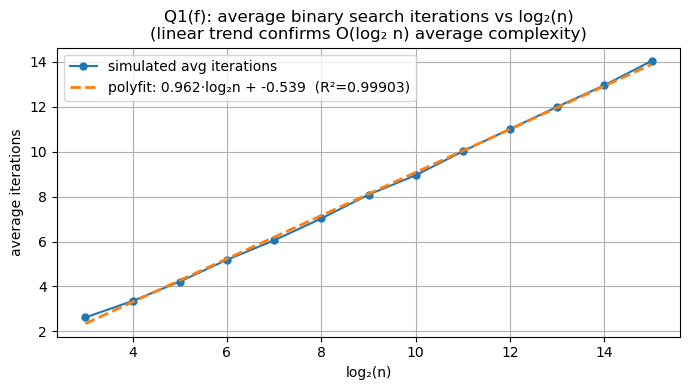

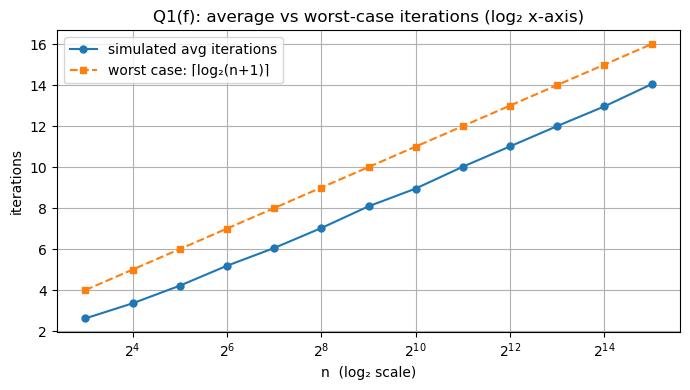

In [5]:
# ==================== Q1(f) ====================
import random
import math
import numpy as np
import matplotlib.pyplot as plt


def binarysearch_count(lst, target):
    """
    Recursive binary search that counts the number of recursive calls made.

    Internally uses a nested helper so that the call count is threaded through
    the recursion as an explicit parameter (pure-functional style, no global
    state or mutable containers).

    Parameters
    ----------
    lst    : list, sorted in non-decreasing order
    target : value to locate

    Returns
    -------
    tuple (result, count)
        result : int index if found, or 'fail'
        count  : int, number of recursive calls including the call that found
                 the target or detected an empty interval.
    """
    def _search(lower, upper, count):
        # Increment the call counter at the start of each recursive call.
        count += 1

        # Base case: empty interval
        if upper < lower:
            return "fail", count

        middle = (lower + upper) // 2

        # Base case: target found
        if lst[middle] == target:
            return middle, count

        # Recurse into left or right half
        if target < lst[middle]:
            return _search(lower, middle - 1, count)
        else:
            return _search(middle + 1, upper, count)

    return _search(0, len(lst) - 1, 0)

def run_tests_Q1_f(num_tests=300, seed=42):
    """
    Random tests for Q1(f): validate correctness and iteration bounds.
    """
    rng = random.Random(seed)
    failed = 0
    randint = rng.randint
    randrange = rng.randrange

    for i in range(1, num_tests + 1):
        n = randint(1, 300)
        lst = sorted(randint(-1000, 1000) for _ in range(n))
        # Hit case only — target is guaranteed to be in the list
        target = lst[randrange(n)]

        out, iters = binarysearch_count(lst, target)

        if out == "fail" or lst[out] != target:
            failed += 1
            print(f"Test {i} failed (hit): target={target}, got={out}")

        max_iters = math.ceil(math.log2(n + 1)) + 1
        if iters < 1 or iters > max_iters:
            failed += 1
            print(
                f"Test {i} failed (iters): n={n}, iters={iters}, "
                f"expected between 1 and {max_iters}"
            )

    if failed == 0:
        print(f"Q1(f): all {num_tests} random tests passed.")
    else:
        print(f"Q1(f): {failed}/{num_tests} random tests failed.")

def simulate_avg_iterations(lengths, trials_per_n=1000, seed=42):
    """
    For each n in lengths, sample random target positions and measure
    average successful-search iterations. Using list = [0, 1, ..., n-1]
    avoids repeated sorting.
    """
    rng = random.Random(seed)
    ns = []
    avg_iters = []

    for n in lengths:
        lst = list(range(n))   # sorted list [0, 1, ..., n-1] — no sorting overhead
        total = sum(binarysearch_count(lst, rng.randrange(n))[1] for _ in range(trials_per_n))

        ns.append(n)
        avg_iters.append(total / trials_per_n)

    return ns, avg_iters

def fit_log_model_with_polyfit(ns, avg_iters):
    """
    Fit avg_iters ≈ a * log2(n) + b with numpy.polyfit and return R^2.
    """
    x = np.log2(np.asarray(ns, dtype=float))
    y = np.asarray(avg_iters, dtype=float)
    a, b = np.polyfit(x, y, 1)
    y_hat = a * x + b

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot if ss_tot != 0 else 0.0)
    return a, b, r2

def report_q1_f_results(ns, avg_iters):
    """
    Print tabular summary and polyfit fit coefficients, then produce two
    diagnostic plots that visually evaluate the O(log2 n) hypothesis.
    """
    print("\nData (n, avg_iterations):")
    for n, av in zip(ns, avg_iters):
        print(f"n={n:6d}  avg_iters={av:.4f}")

    print("\navg_iters / log2(n)  (should be roughly constant if O(log2 n)):")
    log2_ns = [math.log2(n) for n in ns]
    for n, av, log2_n in zip(ns, avg_iters, log2_ns):
        ratio = av / log2_n
        print(f"n={n:6d}  ratio={ratio:.4f}")

    a, b, r2 = fit_log_model_with_polyfit(ns, avg_iters)
    print("\nPolyfit evaluation for O(log2 n) hypothesis:")
    print("Model: avg_iters ≈ a * log2(n) + b")
    print(f"a = {a:.6f}")
    print(f"b = {b:.6f}")
    print(f"R^2 = {r2:.6f}  (close to 1.0 confirms linear relationship with log2 n)")

    # ------------------------------------------------------------------
    # Plot 1: average iterations vs log2(n) with polyfit overlay
    # This directly tests whether avg_iters grows linearly in log2(n),
    # i.e. whether average complexity is O(log2 n).
    # ------------------------------------------------------------------
    x_log = np.array(log2_ns)
    y_arr = np.asarray(avg_iters, dtype=float)
    y_fit = a * x_log + b

    plt.figure(figsize=(7, 4))
    plt.plot(x_log, y_arr, "o-", label="simulated avg iterations", markersize=5)
    plt.plot(x_log, y_fit, "--",
             label=f"polyfit: {a:.3f}·log₂n + {b:.3f}  (R²={r2:.5f})",
             linewidth=2)
    plt.xlabel("log₂(n)")
    plt.ylabel("average iterations")
    plt.title("Q1(f): average binary search iterations vs log₂(n)\n"
              "(linear trend confirms O(log₂ n) average complexity)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # ------------------------------------------------------------------
    # Plot 2: average iterations vs n (semi-log x axis) with worst-case
    # upper bound ceil(log2(n+1)) overlaid for reference.
    # ------------------------------------------------------------------
    ns_arr = np.asarray(ns, dtype=float)
    worst_case = np.ceil(np.log2(ns_arr + 1))

    plt.figure(figsize=(7, 4))
    plt.semilogx(ns_arr, y_arr, "o-", base=2, label="simulated avg iterations",
                 markersize=5)
    plt.semilogx(ns_arr, worst_case, "s--", base=2,
                 label="worst case: ⌈log₂(n+1)⌉", markersize=4)
    plt.xlabel("n  (log₂ scale)")
    plt.ylabel("iterations")
    plt.title("Q1(f): average vs worst-case iterations (log₂ x-axis)")
    plt.legend()
    plt.grid(True, which="both")
    plt.tight_layout()

    plt.show()

# Run Q1(f) tests and simulation.
def run_q1_f(num_tests=20, test_seed=42, trials_per_n=1000, sim_seed=42):
    # Run tests and the average-iteration experiment.
    run_tests_Q1_f(num_tests=num_tests, seed=test_seed)
    lengths = [2**k for k in range(3, 16)]  # 8, 16, 32, ..., 32768
    ns, avg_iters = simulate_avg_iterations(lengths, trials_per_n=trials_per_n, seed=sim_seed)
    report_q1_f_results(ns, avg_iters)
run_q1_f()